In [ ]:
!nvidia-smi -L
!pip -q install faiss-cpu transformers datasets kagglehub
import torch; print('CUDA available:', torch.cuda.is_available())

In [ ]:
import os, sys
REPO_URL = "https://github.com/YOUR_ID/fashion-image-retrieval.git"   # ← YOUR_ID만 본인 계정으로 교체
if not os.path.exists('fashion-image-retrieval'):
    !git clone $REPO_URL
%cd /content/fashion-image-retrieval
sys.path.append('/content/fashion-image-retrieval')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
CACHE = '/content/drive/MyDrive/retrieval_cache'
os.makedirs(CACHE, exist_ok=True)
print('cache:', CACHE)

In [ ]:
import kagglehub
DATA_ROOT = kagglehub.dataset_download("hserdaraltan/deepfashion-inshop-clothes-retrieval")
print('DATA_ROOT =', DATA_ROOT)

In [ ]:
from src import data
splits = data.load_inshop(DATA_ROOT)
query, gallery, train = splits['query'], splits['gallery'], splits['train']
print('raw  ->  query:%d  gallery:%d  train:%d' % (len(query), len(gallery), len(train)))

query   = data.subsample_items(query, n_items=500, seed=0)
gallery = data.cap_gallery(query, gallery, max_gallery=8000, seed=0)
print('use  ->  query:%d  gallery:%d' % (len(query), len(gallery)))

In [ ]:
import numpy as np
from src import embed
E = embed.Embedder('dinov2')
g_vecs = E.encode(gallery.paths, batch_size=64, desc='gallery')
q_vecs = E.encode(query.paths,   batch_size=64, desc='query')
np.save(f'{CACHE}/g_dinov2.npy', g_vecs)
np.save(f'{CACHE}/q_dinov2.npy', q_vecs)
print('embeddings:', g_vecs.shape, q_vecs.shape)

In [ ]:
from src import metrics
nrel = metrics.n_relevant_per_query(query.item_ids, gallery.item_ids)
sims, idx = metrics.search(g_vecs, q_vecs, topk=50)
base = metrics.evaluate(idx, query.item_ids, gallery.item_ids, ks=(1,5,10), n_relevant=nrel)
results = {'dinov2_zeroshot': base}
print('DINOv2 zero-shot:', {k: round(v,3) for k,v in base.items()})

In [ ]:
from src import failures
tags, n_fail = failures.build_gallery(idx, sims, query, gallery,
                                      out_dir='results/failures', k=5, n=60)
print(f'실패 query {n_fail}개 / 자동 태그 분포:', tags)

from IPython.display import Image as IPImage, display
import glob
for p in sorted(glob.glob('results/failures/*.png'))[:6]:
    display(IPImage(p))

In [ ]:
import os, sys, subprocess
os.chdir('/content')
REPO = '/content/fashion-image-retrieval'
subprocess.run(['rm', '-rf', REPO])
r = subprocess.run(['git', 'clone',
                    'https://github.com/UPTOUOY/fashion-image-retrieval.git', REPO],
                   capture_output=True, text=True)
print(r.stderr.strip() or 'clone OK')
print('src:', os.listdir(REPO + '/src') if os.path.isdir(REPO + '/src') else '❌ 없음')
sys.path.insert(0, REPO)
os.chdir(REPO)
print('cwd =', os.getcwd())

Cloning into '/content/fashion-image-retrieval'...
src: ['data.py', 'failures.py', 'finetune_backbone.py', 'embed.py', '__init__.py', 'finetune.py', 'metrics.py']
cwd = /content/fashion-image-retrieval


In [ ]:
import sys
for m in list(sys.modules):
    if m == 'src' or m.startswith('src.'):
        del sys.modules[m]
from src import finetune_backbone as fb, data, metrics

train_s = data.subsample_items(train, n_items=1500, seed=0)

# ★ dinov2-base(768d)로 백본 fine-tune — T4에서 ~12~18분
model_b = fb.finetune_backbone(train_s.paths, train_s.item_ids,
                               epochs=3, P=8, K=4, steps_per_epoch=200,
                               lr=2e-5, unfreeze_blocks=4,
                               model_name='facebook/dinov2-base')

gbb = fb.encode_backbone(model_b, gallery.paths, batch_size=48, desc='gallery(base)')
qbb = fb.encode_backbone(model_b, query.paths,   batch_size=48, desc='query(base)')
_, ixbb = metrics.search(gbb, qbb, topk=50)
results['dinov2base_backbone_ft'] = metrics.evaluate(ixbb, query.item_ids, gallery.item_ids,
                                                     ks=(1,5,10), n_relevant=nrel)

print('base ft  :', {k: round(v,3) for k,v in results['dinov2base_backbone_ft'].items()})
print('small ft :', {k: round(v,3) for k,v in results['dinov2_backbone_ft'].items()})
print('baseline :', {k: round(v,3) for k,v in results['dinov2_zeroshot'].items()})

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

학습 파라미터: 28.36M (unfreeze_blocks=4)
  epoch 0 | step    0 | loss 3.6455
  epoch 0 | step   50 | loss 1.6355
  epoch 0 | step  100 | loss 1.7043
  epoch 0 | step  150 | loss 1.5138
  epoch 1 | step  200 | loss 1.3187
  epoch 1 | step  250 | loss 1.6680
  epoch 1 | step  300 | loss 1.5389
  epoch 1 | step  350 | loss 1.3771
  epoch 2 | step  400 | loss 1.5634
  epoch 2 | step  450 | loss 1.4296
  epoch 2 | step  500 | loss 2.1297
  epoch 2 | step  550 | loss 1.3880


query(base): 100%|██████████| 11/11 [00:14<00:00,  1.32s/it]

base ft  : {'recall@1': 0.874, 'recall@5': 0.954, 'recall@10': 0.968, 'mAP@10': 0.6}
small ft : {'recall@1': 0.852, 'recall@5': 0.946, 'recall@10': 0.962, 'mAP@10': 0.553}
baseline : {'recall@1': 0.492, 'recall@5': 0.664, 'recall@10': 0.726, 'mAP@10': 0.2}


In [ ]:
import sys, numpy as np, torch
for m in list(sys.modules):
    if m=='src' or m.startswith('src.'): del sys.modules[m]
from src import finetune_backbone as fb, data, metrics

# 더 많은 데이터 (1500 → 3000 상품)
train_s = data.subsample_items(train, n_items=3000, seed=0)
print('train imgs:', len(train_s))

# dinov2-base · 6에폭 · 뒤 6블록 학습 (강화)
model_big = fb.finetune_backbone(train_s.paths, train_s.item_ids,
                                 model_name='facebook/dinov2-base',
                                 epochs=6, P=8, K=4, steps_per_epoch=250,
                                 lr=2e-5, unfreeze_blocks=6, size=224)

gbig = fb.encode_backbone(model_big, gallery.paths, batch_size=48, size=224, desc='gallery(big)')
qbig = fb.encode_backbone(model_big, query.paths,   batch_size=48, size=224, desc='query(big)')

# 임베딩 Drive에 저장 (세션 끊겨도 결과 보존)
np.save(f'{CACHE}/g_strong.npy', gbig); np.save(f'{CACHE}/q_strong.npy', qbig)

_, ixbig = metrics.search(gbig, qbig, topk=50)
results['dinov2base_strong'] = metrics.evaluate(ixbig, query.item_ids, gallery.item_ids,
                                                ks=(1,5,10), n_relevant=nrel)
print('strong   :', {k: round(v,3) for k,v in results['dinov2base_strong'].items()})
print('base ft  :', {k: round(v,3) for k,v in results['dinov2base_backbone_ft'].items()})
print('baseline :', {k: round(v,3) for k,v in results['dinov2_zeroshot'].items()})

train imgs: 24097


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

학습 파라미터: 42.54M (unfreeze_blocks=6)
  epoch 0 | step    0 | loss 3.9515
  epoch 0 | step   50 | loss 1.7545
  epoch 0 | step  100 | loss 1.3905
  epoch 0 | step  150 | loss 1.3601
  epoch 0 | step  200 | loss 1.4323
  epoch 1 | step  250 | loss 1.3802
  epoch 1 | step  300 | loss 1.3677
  epoch 1 | step  350 | loss 1.7097
  epoch 1 | step  400 | loss 1.6694
  epoch 1 | step  450 | loss 1.3223
  epoch 2 | step  500 | loss 1.3858
  epoch 2 | step  550 | loss 1.5691
  epoch 2 | step  600 | loss 1.7661
  epoch 2 | step  650 | loss 1.4081
  epoch 2 | step  700 | loss 1.2719
  epoch 3 | step  750 | loss 1.4417
  epoch 3 | step  800 | loss 1.2564
  epoch 3 | step  850 | loss 1.4954
  epoch 3 | step  900 | loss 1.3448
  epoch 3 | step  950 | loss 1.5118
  epoch 4 | step 1000 | loss 1.4171
  epoch 4 | step 1050 | loss 1.6258
  epoch 4 | step 1100 | loss 1.2459
  epoch 4 | step 1150 | loss 1.5782
  epoch 4 | step 1200 | loss 1.6517
  epoch 5 | step 1250 | loss 1.4921
  epoch 5 | step 1300 | loss

query(big): 100%|██████████| 11/11 [00:14<00:00,  1.35s/it]

strong   : {'recall@1': 0.884, 'recall@5': 0.962, 'recall@10': 0.98, 'mAP@10': 0.621}
base ft  : {'recall@1': 0.874, 'recall@5': 0.954, 'recall@10': 0.968, 'mAP@10': 0.6}
baseline : {'recall@1': 0.492, 'recall@5': 0.664, 'recall@10': 0.726, 'mAP@10': 0.2}


In [ ]:
# src 캐시 비우고 최신 코드 로드
import sys
for m in list(sys.modules):
    if m == 'src' or m.startswith('src.'):
        del sys.modules[m]
from src import finetune_backbone as fb, data, metrics

# train 상품 1500개 (약 8천장)
train_s = data.subsample_items(train, n_items=1500, seed=0)
print('train imgs:', len(train_s))

# ★ 백본 직접 학습 (뒤 4블록, 3에폭) — 5~7분
model = fb.finetune_backbone(train_s.paths, train_s.item_ids,
                             epochs=3, P=8, K=4, steps_per_epoch=200,
                             lr=2e-5, unfreeze_blocks=4)

# 학습된 백본으로 재임베딩 → 평가 (2~3분)
gb = fb.encode_backbone(model, gallery.paths, batch_size=64, desc='gallery(ft)')
qb = fb.encode_backbone(model, query.paths,   batch_size=64, desc='query(ft)')
_, ixb = metrics.search(gb, qb, topk=50)
results['dinov2_backbone_ft'] = metrics.evaluate(ixb, query.item_ids, gallery.item_ids,
                                                 ks=(1,5,10), n_relevant=nrel)

print('backbone ft:', {k: round(v,3) for k,v in results['dinov2_backbone_ft'].items()})
print('head-only  :', {k: round(v,3) for k,v in results['dinov2_finetune'].items()})
print('baseline   :', {k: round(v,3) for k,v in results['dinov2_zeroshot'].items()})

train imgs: 11797


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

학습 파라미터: 7.10M (unfreeze_blocks=4)
  epoch 0 | step    0 | loss 3.1276
  epoch 0 | step   50 | loss 1.8679
  epoch 0 | step  100 | loss 1.8023
  epoch 0 | step  150 | loss 1.5556
  epoch 1 | step  200 | loss 1.4144
  epoch 1 | step  250 | loss 1.6462
  epoch 1 | step  300 | loss 1.5584
  epoch 1 | step  350 | loss 1.5256
  epoch 2 | step  400 | loss 1.6152
  epoch 2 | step  450 | loss 1.5471
  epoch 2 | step  500 | loss 2.2212
  epoch 2 | step  550 | loss 1.5801


query(ft): 100%|██████████| 8/8 [00:09<00:00,  1.18s/it]

backbone ft: {'recall@1': 0.852, 'recall@5': 0.946, 'recall@10': 0.962, 'mAP@10': 0.553}
head-only  : {'recall@1': 0.696, 'recall@5': 0.886, 'recall@10': 0.93, 'mAP@10': 0.408}
baseline   : {'recall@1': 0.492, 'recall@5': 0.664, 'recall@10': 0.726, 'mAP@10': 0.2}


In [ ]:
from src import failures
fa = failures.find_failures(ixb, query.item_ids, gallery.item_ids, k=5)
print(f'top-5 실패: baseline 168개 → backbone_ft {len(fa)}개')

top-5 실패: baseline 168개 → backbone_ft 27개


In [ ]:
import pandas as pd, os
order = ['dinov2_zeroshot','dinov2_centercrop','dinov2_finetune','dinov2_backbone_ft']
df = pd.DataFrame({k: results[k] for k in order if k in results}).T[['recall@1','recall@5','recall@10','mAP@10']].round(4)
os.makedirs('results', exist_ok=True)
df.to_markdown('results/metrics.md'); df.to_csv('results/metrics.csv')
print(df)

                    recall@1  recall@5  recall@10  mAP@10
dinov2_zeroshot        0.492     0.664      0.726  0.1998
dinov2_centercrop      0.494     0.662      0.726  0.1997
dinov2_finetune        0.696     0.886      0.930  0.4082
dinov2_backbone_ft     0.852     0.946      0.962  0.5532


In [1]:
!pip -q install faiss-cpu transformers datasets kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 78.5 MB/s eta 0:00:00


In [2]:
import os, sys, subprocess
os.chdir('/content'); REPO='/content/fashion-image-retrieval'
subprocess.run(['rm','-rf',REPO])
subprocess.run(['git','clone','https://github.com/UPTOUOY/fashion-image-retrieval.git',REPO])
sys.path.insert(0,REPO); os.chdir(REPO)
print('src:', os.path.isdir(REPO+'/src'))

src: True


In [3]:
from google.colab import drive; drive.mount('/content/drive')
CACHE='/content/drive/MyDrive/retrieval_cache'

Mounted at /content/drive


In [6]:
import os
os.environ['KAGGLE_USERNAME'] = 'sldjofjij'
os.environ['KAGGLE_KEY']      = 'KGAT_65e15ed81402e0860126b04b47974672'

In [7]:
import kagglehub
DATA_ROOT = kagglehub.dataset_download("hserdaraltan/deepfashion-inshop-clothes-retrieval")

Download already complete (8419284575 bytes).
Extracting files...


In [12]:
import os, glob
# 옛 split로 계산된 낡은 임베딩 캐시 제거 → A에서 새로 계산됨
for f in glob.glob(f'{CACHE}/*.npy'):
    print('삭제:', f)
    os.remove(f)

삭제: /content/drive/MyDrive/retrieval_cache/g_dinov2.npy
삭제: /content/drive/MyDrive/retrieval_cache/q_dinov2.npy
삭제: /content/drive/MyDrive/retrieval_cache/g_strong.npy
삭제: /content/drive/MyDrive/retrieval_cache/q_strong.npy


In [13]:
from src import data
sp = data.load_inshop(DATA_ROOT)
query, gallery, train = sp['query'], sp['gallery'], sp['train']
query = data.subsample_items(query, n_items=500, seed=0)
gallery = data.cap_gallery(query, gallery, max_gallery=8000, seed=0)
print('query', len(query), 'gallery', len(gallery))

주석파일 없음 → 폴더 구조에서 split 자동 구성
query 500 gallery 8000


In [16]:
from src import embed

emb = embed.Embedder(backbone='dinov2')
g0 = emb.encode(gallery.paths, batch_size=64, desc='gallery')
q0 = emb.encode(query.paths,   batch_size=64, desc='query')

import numpy as np
np.save(f'{CACHE}/g_dinov2.npy', g0)
np.save(f'{CACHE}/q_dinov2.npy', q0)
print('저장 완료:', g0.shape, q0.shape)

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

query: 100%|██████████| 8/8 [00:08<00:00,  1.00s/it]

저장 완료: (8000, 384) (500, 384)


In [17]:
import numpy as np
from src import metrics, failures
nrel = metrics.n_relevant_per_query(query.item_ids, gallery.item_ids)
train_s = data.subsample_items(train, n_items=1500, seed=0)
ev = lambda ix: metrics.evaluate(ix, query.item_ids, gallery.item_ids, ks=(1,5,10), n_relevant=nrel)
results = {}
g0 = np.load(f'{CACHE}/g_dinov2.npy'); q0 = np.load(f'{CACHE}/q_dinov2.npy')
sims0, idx0 = metrics.search(g0, q0, topk=50)
results['dinov2_zeroshot'] = ev(idx0)
failures.build_gallery(idx0, sims0, query, gallery, out_dir='results/failures', k=5, n=60)
print('baseline:', results['dinov2_zeroshot'])

baseline: {'recall@1': 0.538, 'recall@5': 0.71, 'recall@10': 0.79, 'mAP@10': 0.21192501637692113}


In [18]:
from src import fashion
import numpy as np

fe = fashion.FashionEmbedder()
gf = fe.encode(gallery.paths, desc='fashion-g')
qf = fe.encode(query.paths,   desc='fashion-q')
np.save(f'{CACHE}/g_fashion.npy', gf)
np.save(f'{CACHE}/q_fashion.npy', qf)

_, idxf = metrics.search(gf, qf, topk=50)
print('FashionCLIP zero-shot:', ev(idxf))

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

fashion-q: 100%|██████████| 8/8 [00:10<00:00,  1.31s/it]

FashionCLIP zero-shot: {'recall@1': 0.892, 'recall@5': 0.962, 'recall@10': 0.964, 'mAP@10': 0.5617640586419753}


In [19]:
model = fashion.finetune_fashion(
    train.paths, train.item_ids,
    epochs=3, P=8, K=4, steps_per_epoch=200, lr=1e-5, unfreeze_layers=4,
)
gft = fashion.encode_fashion(model, gallery.paths, desc='fashion-ft-g')
qft = fashion.encode_fashion(model, query.paths,   desc='fashion-ft-q')
np.save(f'{CACHE}/g_fashion_ft.npy', gft)
np.save(f'{CACHE}/q_fashion_ft.npy', qft)

_, idxft = metrics.search(gft, qft, topk=50)
print('FashionCLIP fine-tune:', ev(idxft))

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

학습 파라미터: 28.75M (FashionCLIP, unfreeze_layers=4)
  epoch 0 | step    0 | loss 2.9654
  epoch 0 | step   50 | loss 1.8042
  epoch 0 | step  100 | loss 1.7379
  epoch 0 | step  150 | loss 1.8371
  epoch 1 | step  200 | loss 1.9498
  epoch 1 | step  250 | loss 1.6992
  epoch 1 | step  300 | loss 1.4110
  epoch 1 | step  350 | loss 1.4929
  epoch 2 | step  400 | loss 1.4610
  epoch 2 | step  450 | loss 1.6785
  epoch 2 | step  500 | loss 1.5457
  epoch 2 | step  550 | loss 1.6211


fashion-ft-q: 100%|██████████| 8/8 [00:10<00:00,  1.31s/it]

FashionCLIP fine-tune: {'recall@1': 0.932, 'recall@5': 0.976, 'recall@10': 0.982, 'mAP@10': 0.6628152695893171}


In [20]:
from src import finetune_backbone as ftb
import numpy as np, torch

model_s = ftb.finetune_backbone(
    train.paths, train.item_ids,
    epochs=3, P=8, K=4, steps_per_epoch=200, lr=2e-5,
    unfreeze_blocks=4, model_name='facebook/dinov2-small',
)
gS = ftb.encode_backbone(model_s, gallery.paths, desc='dinoS-ft-g')
qS = ftb.encode_backbone(model_s, query.paths,   desc='dinoS-ft-q')
np.save(f'{CACHE}/g_dinovS_ft.npy', gS); np.save(f'{CACHE}/q_dinovS_ft.npy', qS)
torch.save(model_s.state_dict(), f'{CACHE}/dinovS_ft.pt')   # attention·크래시대비

_, idxS = metrics.search(gS, qS, topk=50)
print('DINOv2-small fine-tune (같은 split):', ev(idxS))

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

학습 파라미터: 7.10M (unfreeze_blocks=4)
  epoch 0 | step    0 | loss 3.8293
  epoch 0 | step   50 | loss 1.8656
  epoch 0 | step  100 | loss 1.7011
  epoch 0 | step  150 | loss 1.8495
  epoch 1 | step  200 | loss 1.8133
  epoch 1 | step  250 | loss 1.8127
  epoch 1 | step  300 | loss 1.7085
  epoch 1 | step  350 | loss 1.5179
  epoch 2 | step  400 | loss 1.4301
  epoch 2 | step  450 | loss 1.7436
  epoch 2 | step  500 | loss 1.6133
  epoch 2 | step  550 | loss 1.8344


dinoS-ft-q: 100%|██████████| 8/8 [00:08<00:00,  1.08s/it]


DINOv2-small fine-tune (같은 split): {'recall@1': 0.882, 'recall@5': 0.954, 'recall@10': 0.968, 'mAP@10': 0.5767099996850592}


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

/content/fashion-image-retrieval/src/attention.py:72: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/content/fashion-image-retrieval/src/attention.py:72: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/content/fashion-image-retrieval/src/attention.py:72: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/content/fashion-image-retrieval/src/attention.py:72: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/content/fashion-image-retrieval/src/attention.py:73: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.savefig(out_path, dpi=120, bbox_inches="tight")
/content/fashion-image-retrieval/src/attention.py:73: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.savefig(out_path, dp

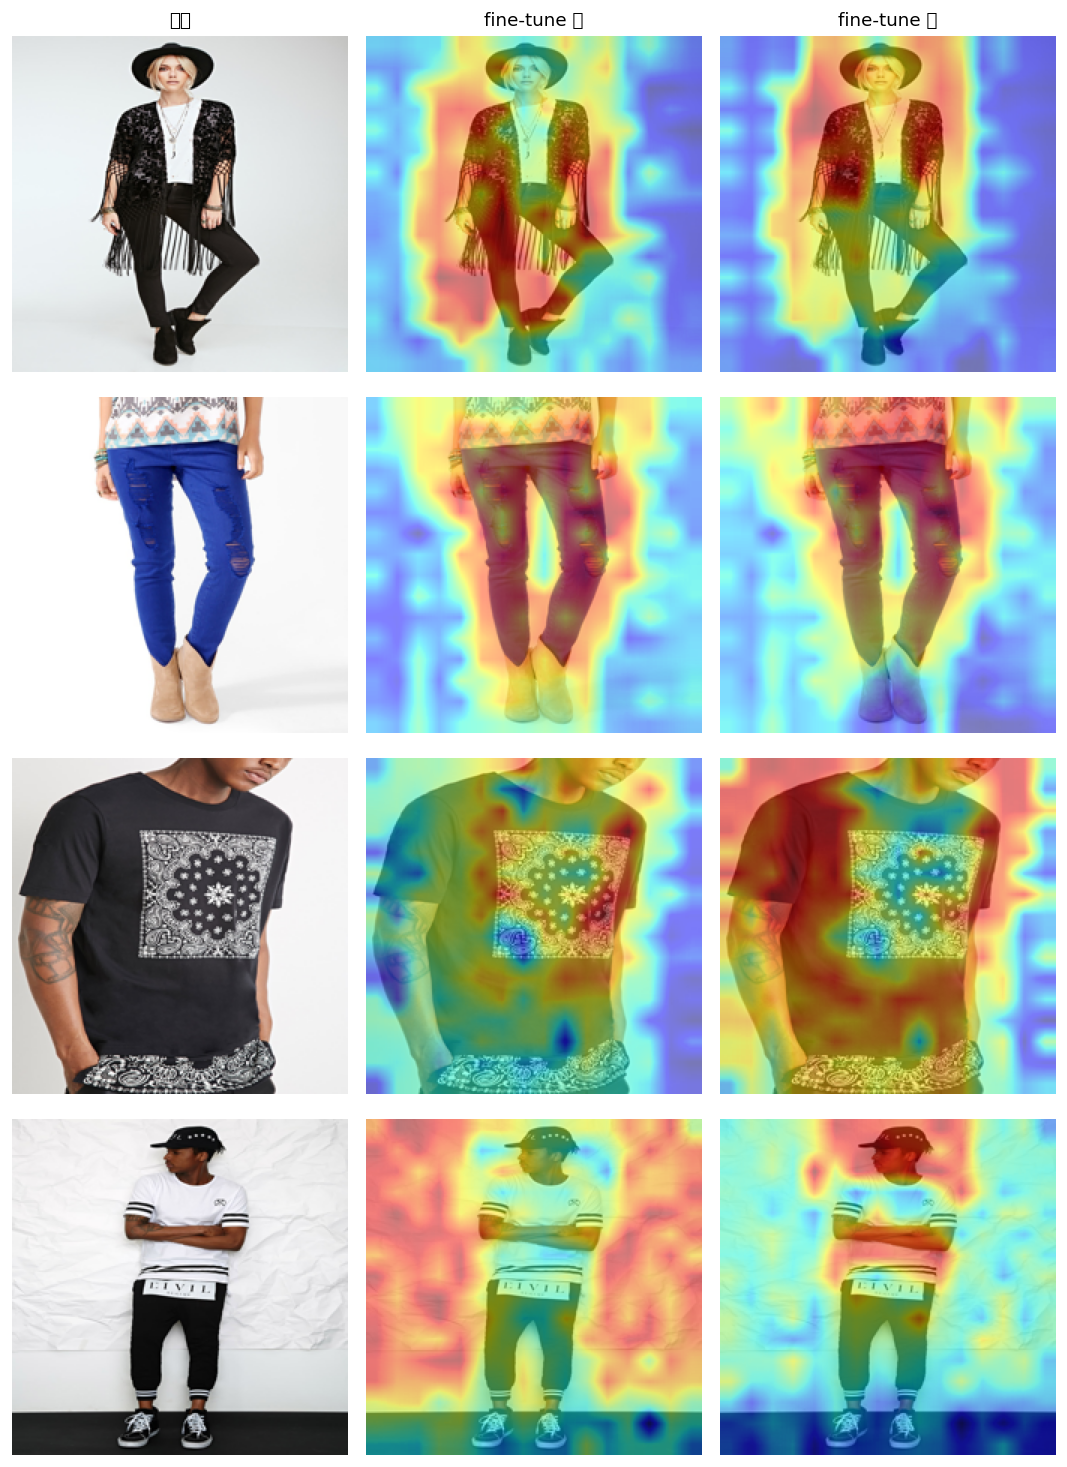

In [21]:
from src import attention as att
import os, shutil
os.makedirs('results', exist_ok=True)

before = att.load_dinov2_eager('facebook/dinov2-small')
after  = att.load_dinov2_eager('facebook/dinov2-small', state_dict=model_s.state_dict())

att.compare_figure(before, after, query.paths[:4], 'results/attention_compare.png')
shutil.copy('results/attention_compare.png', f'{CACHE}/attention_compare.png')  # Drive 보존

from IPython.display import Image as IPImage
IPImage('results/attention_compare.png')